In [1]:
import numpy as np
import matplotlib.pyplot as plt
# from scipy.interpolate import PchipInterpolator, CubicSpline
from scipy.signal import savgol_filter, butter, filtfilt
from scipy.optimize import curve_fit

from functions import *

In [60]:
### ---------- Define the values -----------
n_s_val = 1.4620 #substrate refractive index
n_o_val = 1 #air refractive index

# wavs = np.linspace(750, 1650, 200) #wavelengths
wavs = np.arange(750, 1650, 0.4)

d_f = 4000 #thickness
# d_f = 8e3 - 5e3*(wavs-wavs[0])/(wavs[-1]-wavs[0])
# d_f = 8e3 - 10e2*(wavs-wavs[0])/(wavs[-1]-wavs[0])-3e3*(wavs-wavs[0])**2/(wavs[-1]-wavs[0])**2
# d_f = 8e3*np.log10(10-(wavs-wavs[0])/(wavs[-1]-wavs[0]))

E0, Ed = 5.55, 8.90
n_f_val = n_Wemple_DiDomenico(wavs, E0, Ed) #refractive index film
# n_f_val = 1.4*np.ones(len(wavs))

n_f_smaller = np.mean(n_f_val) < np.mean(n_s_val)

Eu = 93.8e-3
# Eu = 85e-3
alpha0 = 10**(6-1/(np.log(10)*Eu)*3) #cm^-1
# alpha0 = 1e-5
print(f'alpha0 = {alpha0}')
alpha = alpha_Urbach(wavs, alpha0, Eu) #absorption coefficient (cm^-1)
kappa_f = alpha*wavs*10**-7/(4*np.pi) #film's imaginary refractive index
# kappa_f = 1e-2
phi_im = 2*np.pi*kappa_f/wavs * d_f
x_val = np.exp(-2*phi_im) #attenuation factor

r1 = r_s(0, n_s_val/n_f_val)
r2 = r_s(0, n_o_val/n_f_val)

R_FP = np.absolute(R_FP_com_perda(r1, r2, wavs, n_f_val, d_f, kappa_f))
R_s = (n_s_val-1)**2/(n_s_val+1)**2

R_real = R_FP/R_s

alpha0 = 1.288203833794999e-08


m0_max = 17.49212927609846
Maximum frequency = 0.02362656403046384 nm^-1
Butterworth cuttoff freq = 0.04725312806092768
d real = 4000 nm; m0 real = 17.5
n1_std propagation of error = 0.16025912990997834
n1_rmse = 0.004734504641598834
First linear fit r^2 = 0.9999420145965583 (hermite, low-pass): d = 4013.112297018207 +/- 7.203059331832821 nm; m0 = 17.54814835101015 +/- 0.023546802584147333
Second linear fit r^2 = 0.999928545293305 (hermite, low-pass): d = 3998.7436014299215 +/- 1.710367745837731 nm; m0 fixed = 17.5
d_std estimate 1= 11.661834332365942
d_std estimate 2 = 8.069840910293134
d_std estimate 3 = 14.470133742160625
Root mean squared error of n (hermite, low-pass) = 0.001744649913564062
n2_std estimate = 0.00594204252384874
Root mean squared error of: x_M = 0.004184037831638138, x_m = 0.00656338641277044, x_Mm = 0.00413232716181691


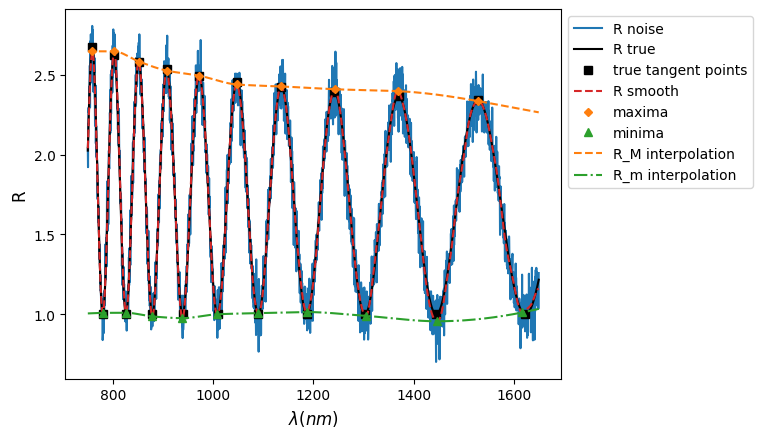

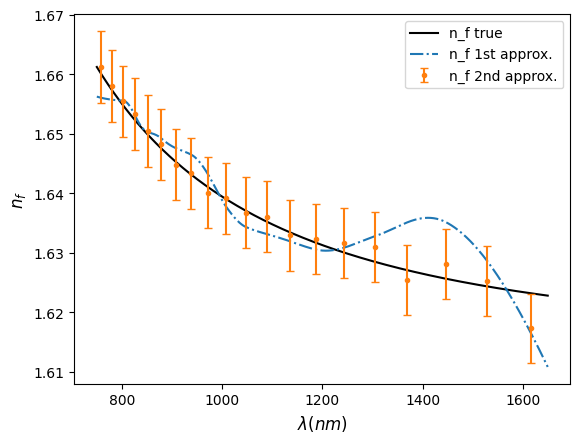

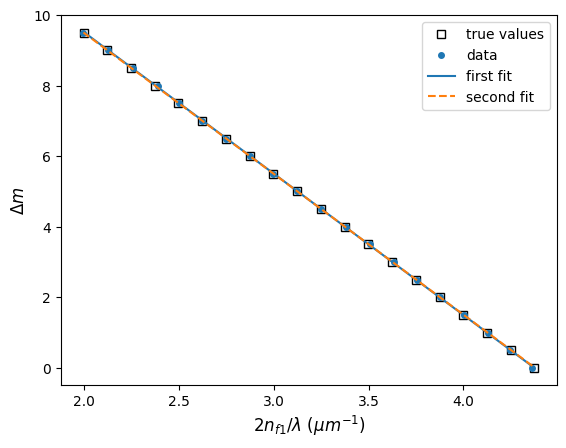

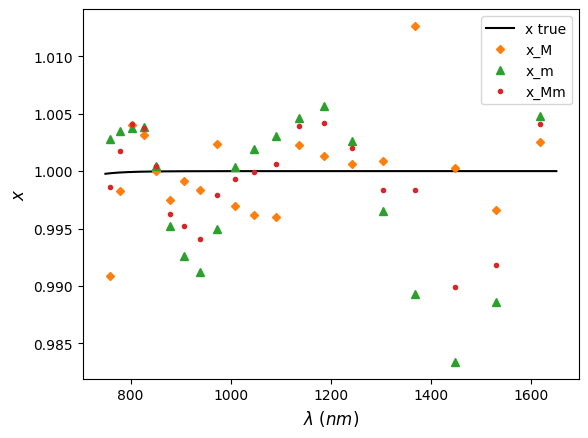

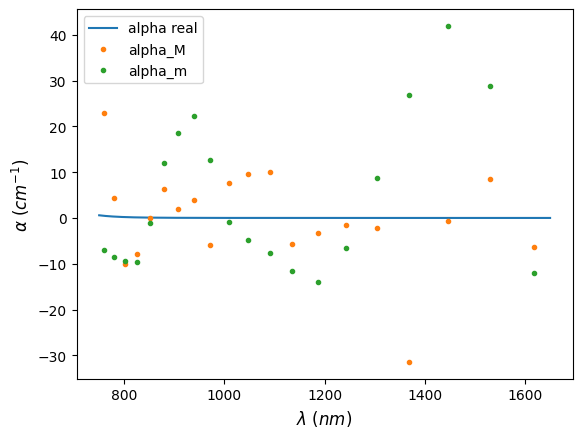

In [62]:
#Calculate the tangent points
i_tan, _ = find_peaks((4*n_f_val*d_f/wavs)%1)
m_max = 2*n_f_val[i_tan[0]]*d_f/wavs[i_tan[0]]
print(f'm0_max = {m_max}')
# lamb_1 = (2*n_f_val*d_f/(m_max))[0]
# lamb_2 = (2*n_f_val*d_f/(m_max-0.5))[0]
# freq_max = 0.5/(lamb_2-lamb_1)
freq_max = (2*n_f_val[0]*d_f)/wavs[0]**2
print(f'Maximum frequency = {freq_max} nm^-1')

#Add noise
std_noise = 0.09
noise = np.random.normal(0, std_noise, len(wavs))
# noise = -std_noise*np.ones(len(R_real))
R_noise = R_real+noise
# R_noise = np.load('R_noise_sim.npy')

#Savitzky-Golay Filter
R_savgol = savgol_filter(R_noise, 9, 3)

#Low-pass Butterworth filter
fs = 1/(wavs[1]-wavs[0])
cutoff = 2*freq_max
# cutoff = 0.064
R_low_pass, b, a = butter_filter(R_noise, cutoff, 5, fs = fs, return_ba = True)
print(f'Butterworth cuttoff freq = {cutoff}')

#Plots
fig1 = plt.figure(1)
plt.plot(wavs, R_noise, label = 'R noise')
plt.plot(wavs, R_real, 'k', label = 'R true')
plt.plot(wavs[i_tan], R_real[i_tan], 'sk', label = 'true tangent points')
# plt.plot(wavs, R_savgol, 'C4--', label = 'R savgol')
plt.plot(wavs, R_low_pass, 'C3--', label = 'R smooth')

fig2 = plt.figure(2)
plt.plot(wavs, n_f_val, 'k', label = 'n_f true')


#Choose the filters and interpolation to use in analysis
# R_filtered = {'savgol': R_savgol, 'low-pass': R_low_pass}
# R_filtered = {'no_filter': R_real}
R_filtered = {'low-pass': R_low_pass}
# R_filtered = {'savgol': R_savgol}
interpol = 'hermite'
# interpol = 'cubic_spline'

for filter_name, R in R_filtered.items():

    #Calculate the values
    results = calc_values(R, wavs, n_s_val, interpol, n_f_smaller)
    extr = np.sort(np.append(results['max_R'], results['min_R']))
    m_spacing = np.arange(0, (len(extr))*0.5, 0.5)
    x = 2*results['n1'][extr]/wavs[extr]

    #Calculate the true m0 value
    i_0real = i_tan[np.argmin(np.abs(i_tan-extr[0]))]
    m0_real = np.round(2*n_f_val[i_0real]*d_f/wavs[i_0real], 1)
    print(f'd real = {d_f} nm; m0 real = {m0_real}')

    #Calculate absorption
    use_n = results['n2']
    x_M = calc_x_M(n_s_val, use_n, results['R_M_interp'](wavs[extr]), n_f_smaller)
    x_m = calc_x_m(n_s_val, use_n, results['R_m_interp'](wavs[extr]), n_f_smaller)
    x_Mm = calc_x_Mm(n_s_val, use_n, results['R_M_interp'](wavs[extr]), results['R_m_interp'](wavs[extr]))

    alpha_M = -np.log(x_M)/(results['d2']*10**-7)
    alpha_m = -np.log(x_m)/(results['d2']*10**-7)
    alpha_Mm = -np.log(x_Mm)/(results['d2']*10**-7)

    #Print the values
    n1_std = n1_std_estimate(results['n1'], results['R_M_interp'](wavs), results['R_m_interp'](wavs), std_noise, std_noise)
    n1_rmse = rmse(results['n1'], n_f_val)
    print(f'n1_std propagation of error = {np.mean(n1_std)}')
    print(f'n1_rmse = {n1_rmse}')
    # print(f'{np.mean(n1_std/n1_rmse)}')

    print(f'First linear fit r^2 = {results["r2_1"]} ({interpol}, {filter_name}): d = {results["d1"]} +/- {results["d1_std"]} nm; m0 = {results["m0_aprox"]} +/- {results["m0_aprox_std"]}')

    print(f'Second linear fit r^2 = {results["r2_2"]} ({interpol}, {filter_name}): d = {results["d2"]} +/- {results["d2_std"]} nm; m0 fixed = {results["m0_exact"]}')
    d_std = d_std_estimate(results["d2"], wavs, wavs[1]-wavs[0], results['n1'], n1_rmse)
    d_std2 = d_std_estimate2(results["d2"], 2*results["n1"][extr]/wavs[extr], results["m0_exact"])
    d_std3 = d2_std_estimate(results['d2_std'], np.abs(results['m0_exact']-results['m0_aprox']), x) #results['m0_aprox_std'],np.abs(results['m0_exact']-results['m0_aprox'])
    print(f'd_std estimate 1= {np.mean(d_std)}')
    print(f'd_std estimate 2 = {np.mean(d_std2)}')
    print(f'd_std estimate 3 = {d_std3}')

    n_rmse = rmse(results['n2'], n_f_val[extr])
    std_wav = (wavs[1]-wavs[0])/2
    n2_std = n2_std_estimate(results['n2'], results['d2'], d_std3, wavs[extr], std_wav)
    print(f'Root mean squared error of n ({interpol}, {filter_name}) = {n_rmse}')
    print(f'n2_std estimate = {np.mean(n2_std)}')

    x_M_rmse, x_m_rmse, x_Mm_rmse = rmse(x_M, x_val[extr]), rmse(x_m, x_val[extr]), rmse(x_Mm, x_val[extr])
    print(f'Root mean squared error of: x_M = {x_M_rmse}, x_m = {x_m_rmse}, x_Mm = {x_Mm_rmse}')

    font_size = 12
    #Plots
    plt.figure(1)
    plt.plot(wavs[results['max_R']], R[results['max_R']], 'DC1', label = 'maxima', markersize = 4)
    plt.plot(wavs[results['min_R']], R[results['min_R']], '^C2', label = 'minima')
    plt.plot(wavs, results['R_M_interp'](wavs), '--C1', label = f'R_M interpolation')
    plt.plot(wavs, results['R_m_interp'](wavs), '-.C2', label = f'R_m interpolation')

    plt.figure(2)
    plt.plot(wavs, results['n1'], '-.', label = f'n_f 1st approx.')
    plt.errorbar(wavs[extr], results['n2'], yerr = n2_std, fmt = '.', capsize = 3, label = f'n_f 2nd approx.')

    factor, xlabel = 10**3, r'$2n_{f1}/\lambda\ ({\mu m}^{-1})$'
    fig3 = plt.figure(3)
    plt.plot(2*n_f_val[i_tan]/wavs[i_tan]*factor, np.arange(0, len(i_tan)/2, 0.5)-np.argmin(np.abs(i_tan-extr[0]))/2, 'sk', markerfacecolor='none', label = 'true values')
    plt.plot(x*factor, m_spacing, 'o', label = f'data', markersize = 4)
    plt.plot(x*factor, -x*results['d1']+results['m0_aprox'], '-C0', label = f'first fit') #f'first fit ({interpol}, {filter_name})'
    plt.plot(x*factor, -x*results['d2']+results['m0_exact'], '--', label = f'second fit')

    fig4 = plt.figure(4)
    plt.plot(wavs, x_val, 'k', label = 'x true')
    plt.plot(wavs[extr], x_M, 'DC1', label = 'x_M', markersize = 4)
    plt.plot(wavs[extr], x_m, '^C2', label = 'x_m')
    plt.plot(wavs[extr], x_Mm, '.C3', label = 'x_Mm')

    fig5 = plt.figure(5)
    plt.plot(wavs, -np.log(x_val)/(d_f*10**-7), label = 'alpha real')
    plt.plot(wavs[extr], alpha_M, '.', label = 'alpha_M')
    plt.plot(wavs[extr], alpha_m, '.', label = 'alpha_m')
    # plt.plot(wavs[extr], alpha_Mm, '.', label = 'alpha_Mm')

plt.figure(1)
plt.legend(bbox_to_anchor=(1, 1),loc='upper left')
plt.xlabel(r'$\lambda (nm)$', fontsize = font_size)
plt.ylabel('R', fontsize = font_size)

plt.figure(2)
plt.legend()
plt.xlabel(r'$\lambda (nm)$', fontsize = font_size)
plt.ylabel(r'$n_f$', fontsize = font_size)

plt.figure(3)
plt.ylabel(r'$\Delta m$', fontsize = font_size)
plt.xlabel(xlabel, fontsize = font_size)
plt.legend()

plt.figure(4)
plt.ylabel(r'$x$', fontsize = font_size)
plt.xlabel(r'$\lambda\ (nm)$', fontsize = font_size)
plt.legend()

plt.figure(5)
plt.ylabel(r'$\alpha\ (cm^{-1})$', fontsize = font_size)
plt.xlabel(r'$\lambda\ (nm)$', fontsize = font_size)
plt.legend()

plt.show()

# #--Save figure--
# direc = "Figuras/"
# fmt = 'pdf'
# dic = {'R_sim': fig1, 'n_sim': fig2, 'lin_fit_sim': fig3, f'x_sim_alpha0_{alpha0:.0e}': fig4}
# # save = ['R_sim', 'n_sim', 'lin_fit_sim', 'x_sim']
# save = [f'x_sim_alpha0_{alpha0:.0e}']
# for name in save:
#     dic[name].savefig(f'{direc}{name}.{fmt}', format=fmt, bbox_inches='tight')

In [ ]:
## --- Save R_noise to use the same values in future calculations if necessary ---
# np.save('R_noise_sim.npy', R_noise)

In [50]:
#
Sxx = np.sum((x-np.mean(x))**2)
slope_fix = np.sum(x*(m_spacing-m0_real))/np.sum(x**2)
slope_free = np.sum((x-np.mean(x))*(m_spacing-np.mean(m_spacing)))/Sxx
interc_free = np.mean(m_spacing)-slope_free*np.mean(x)

RSS_free = np.sum((x*slope_free+interc_free-m_spacing)**2)
RSS_fix = np.sum((x*slope_fix+m0_real-m_spacing)**2)
# print(f'{RSS_free}, {RSS_fix}')
n = len(x)
slope_fix_err = np.sqrt(RSS_fix / ((n-1)*np.sum(x**2)))
slope_free_err = np.sqrt(RSS_free / ((n-2)*Sxx))
interc_free_err = np.sqrt(slope_free_err**2*np.sum(x**2) / n)

slope_fix_err2 = np.sqrt(slope_fix_err**2 + (interc_free_err*np.sum(x)/np.sum(x**2))**2)

slope_fix_err3 = slope_free_err*np.sqrt(1 + Sxx/np.sum(x**2)*(RSS_fix/(n-1)*(n-2)/RSS_free-1))


print(f'Free intercept: Slope = {slope_free} +/- {slope_free_err} or {-results["d1"]} +/- {results["d1_std"]}')
print(f'Free intercept: Intercept = {interc_free} +/- {interc_free_err} or {results["m0_aprox"]} +/- {results["m0_aprox_std"]}')
print(f'Fixed intercept: Slope = {slope_fix} +/- {slope_fix_err} or {-results["d2"]} +/- {results["d2_std"]}')
print(f'slope_fix_err modified: {slope_fix_err2}, {slope_fix_err3}')

Free intercept: Slope = -6013.676541602676 +/- 9.241241848070453 or -6013.676541515025 +/- 9.241241884651417
Free intercept: Intercept = 26.046223223951937 +/- 0.02996602706252484 or 26.04622322367434 +/- 0.029966027099226404
Fixed intercept: Slope = -5999.753588008703 +/- 2.0306676452421577 or -5999.7535880009455 +/- 2.030667637667375
slope_fix_err modified: 9.251710963326113, 9.251710963326115


d1 (nm) = 6014.059970087244 +/- 9.241831111649653; m0_aprox = 26.047437599968223 +/- 0.04194298889585514
d2 (nm) = 5999.772832332049 +/- 2.0306741664074877


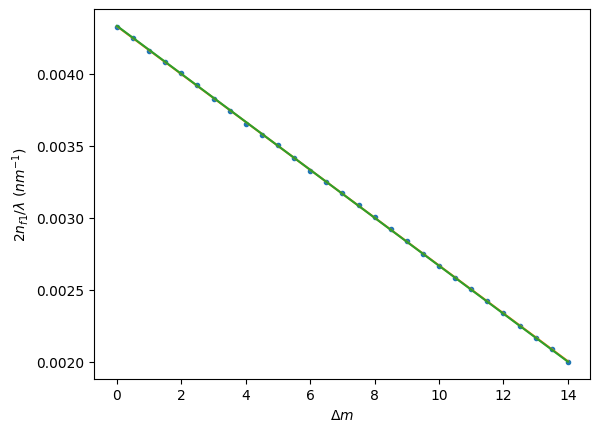

In [51]:
#--- With x axis = delta_m and y axis = 2*n_f1/wavelength ---
p1, cov1 = curve_fit(linear_func, m_spacing, x)
std1, r2_1 = np.sqrt(np.diag(cov1)), r_squared(x, linear_func(m_spacing, p1[0], p1[1]))
m0_aprox_std = np.sqrt((std1[1]/p1[0])**2+(std1[0]*p1[1]/p1[0]**2)**2)

# m0_real = 8.5

p2, cov2 = curve_fit(lambda delta_m, slope: linear_func(delta_m-m0_real, slope, 0), m_spacing, x)
std2, r2_2 = np.sqrt(np.diag(cov2)), r_squared(x, linear_func(m_spacing-m0_real, p2[0], 0))

# if ((vales_R[0]<picos_R[0]))%2: #first value is a minimum
#     m0_real = round(p1[1]) #round to nearest integer
# else:
#     m0_real = np.floor(p1[1]) + 0.5 #round to nearest half-integer

# # x_aux = x[:,np.newaxis]
# # slope2, res, _, _ = np.linalg.lstsq(x_aux, m_spacing-m0_real)
# # sigma2 = res/(len(x)-1)
# # slope_se = np.sqrt(sigma2/np.sum(x**2))
# p2, cov2 = curve_fit(lambda x, m: linear_func(x, m, m0_real), x, m_spacing)
# std2, r2_2 = np.sqrt(np.diag(cov2)), r_squared(m_spacing, linear_func(x, p2[0], m0_real))

print(f'd1 (nm) = {-1/p1[0]} +/- {std1[0]/p1[0]**2}; m0_aprox = {-p1[1]/p1[0]} +/- {m0_aprox_std}')
print(f'd2 (nm) = {-1/p2[0]} +/- {std2[0]/p2[0]**2}')

plt.plot(m_spacing, x, '.')
plt.plot(m_spacing, linear_func(m_spacing, p1[0], p1[1]))
plt.plot(m_spacing, linear_func(m_spacing-m0_real, p2[0], 0))
plt.xlabel(r'$\Delta m$')
plt.ylabel(r'$2n_{f1}/\lambda\ ({nm}^{-1})$')
plt.show()

# Several Measurements

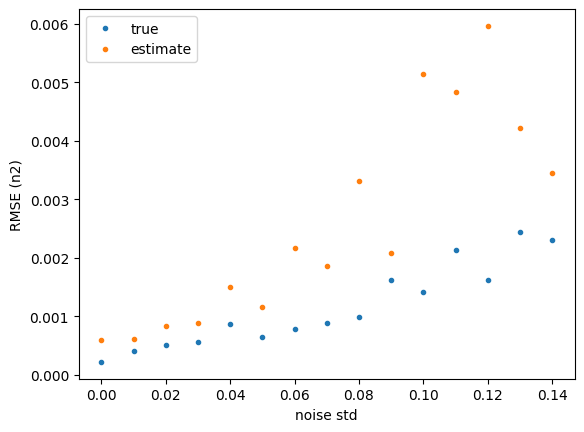

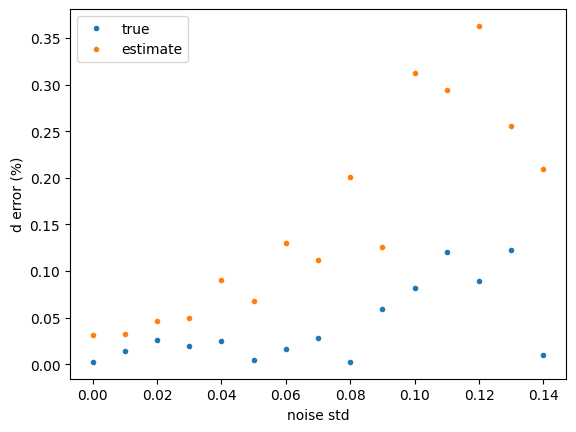

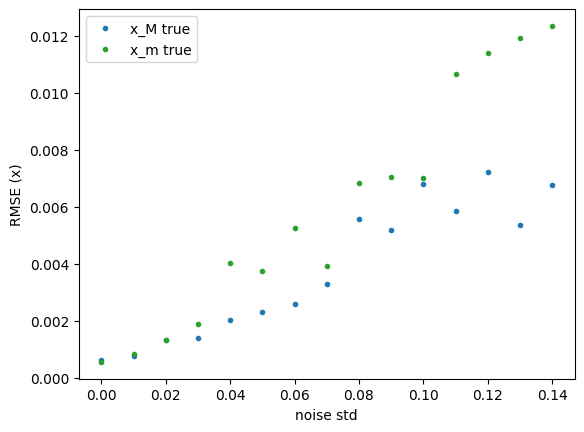

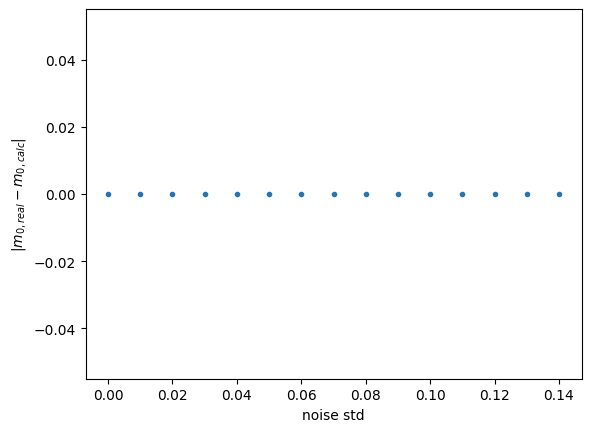

In [73]:
# --- Define values of base case: ---
n_s_val, n_o_val = 1.462, 1
d_f = 6000 #nm
E0, Ed = 5.55, 8.9 #eV, eV
alpha0, Eu = 1.29e-6, 93.8e-3 #cm^-1, eV
noise_std = 0.05
wavs = np.arange(750, 1650, 0.4)

# --- Define list of values to change ---
# lst, var_label = np.arange(1000, 15001, 1000), "d_f (nm)"
lst, var_label = np.arange(0, 0.15, 0.01), "noise std"
# lst, var_label = 10**np.arange(-8., -3, 1), "alpha0"
# lst, var_label = np.arange(0, 10), "# measurement" #don't change anything

n2_err_lst, n2_err_est_lst = [], []
d2_err_lst, d2_err_est_lst = [], []
xM_err_lst, xm_err_lst = [], []
m0_err_lst = []

for i, var in enumerate(lst):
    if var_label == "d_f (nm)":
        d_f = var
    elif var_label == "noise std":
        noise_std = var
    elif var_label == "alpha0":
        alpha0 = var

    #---- Calculate R_real, R_noise, and R_filt ----
    n_f_val = n_Wemple_DiDomenico(wavs, E0, Ed)
    alpha_val = alpha_Urbach(wavs, alpha0, Eu) #cm^-1
    kappa_f = alpha_val*wavs*10**-7/(4*np.pi)
    x_val = np.exp(-alpha_val*d_f*10**-7)

    r1 = r_s(0, n_s_val/n_f_val)
    r2 = r_s(0, n_o_val/n_f_val)

    R_FP = np.absolute(R_FP_com_perda(r1, r2, wavs, n_f_val, d_f, kappa_f))
    R_s = (n_s_val-1)**2/(n_s_val+1)**2

    R_real = R_FP/R_s
    R_noise = R_real+np.random.normal(0, noise_std, len(wavs))

    #Calculate the cutoff frequency from the maximum frequency of the signal
    i_tan, _ = find_peaks((4*n_f_val*d_f/wavs)%1)
    m_max = 2*n_f_val[i_tan[0]]*d_f/wavs[i_tan[0]]
    # print(f'm0_max = {m_max}')
    freq_max = (2*n_f_val[0]*d_f)/wavs[0]**2
    # print(f'Maximum frequency = {freq_max} nm^-1')
    cutoff = 2*freq_max

    # R_filt = savgol_filter(R_noise, 13, 3)
    R_filt = butter_filter(R_noise, cutoff, fs = 1/(wavs[1]-wavs[0]))

    # --- Calculate results ---
    results = calc_values(R_filt, wavs, n_s_val, "hermite")
    extr = np.sort(np.append(results['max_R'], results['min_R']))
    m0_real = np.round(4*n_f_val[extr[0]]*d_f/wavs[extr[0]])/2

    x_M = calc_x_M(n_s_val, results['n2'], results['R_M_interp'](wavs[extr]))
    x_m = calc_x_m(n_s_val, results['n2'], results['R_m_interp'](wavs[extr]))

    # --- Calculate error and error estimates ---
    n_rmse = rmse(results['n2'], n_f_val[extr])
    d_err = np.abs(results['d2'] - d_f)/d_f
    # xM_rmse = rmse(x_M, x_val[extr])
    xM_rmse = np.mean(np.abs(x_M-x_val[extr])/x_val[extr])
    xm_rmse = rmse(x_m, x_val[extr])

    # d_std_est = results['d2_std'] #d_std calculated directly from the fit with fixed intercept (underestimated)
    d_std_est = d2_std_estimate(results['d2_std'], results['m0_aprox_std'], 2*results['n1'][extr]/wavs[extr]) #results['m0_aprox_std'],np.abs(results['m0_exact']-results['m0_aprox'])
    n2_std_est = n2_std_estimate(results['n2'], results['d2'], d_std_est, wavs[extr], (wavs[1]-wavs[0])/2)
        
    n2_err_lst.append(n_rmse)
    d2_err_lst.append(d_err)
    xM_err_lst.append(xM_rmse)
    xm_err_lst.append(xm_rmse)
    n2_err_est_lst.append(np.mean(n2_std_est))
    d2_err_est_lst.append(d_std_est/results['d2'])
    m0_err_lst.append(np.abs(m0_real-results['m0_exact']))

plt.figure(1)

if var_label == "alpha0":
    plt.semilogx(lst, n2_err_lst, '.', label = 'true')
    plt.semilogx(lst, n2_err_est_lst, '.', label = 'estimate')
else:
    plt.plot(lst, n2_err_lst, '.', label = 'true')
    plt.plot(lst, n2_err_est_lst, '.', label = 'estimate')

plt.xlabel(var_label)
plt.ylabel("RMSE (n2)")
plt.legend()

plt.figure(2)
if var_label == "alpha0":
    plt.semilogx(lst, np.array(d2_err_lst)*100, '.', label = 'true')
    plt.semilogx(lst, np.array(d2_err_est_lst)*100, '.', label = 'estimate')
else:
    plt.plot(lst, np.array(d2_err_lst)*100, '.', label = 'true')
    plt.plot(lst, np.array(d2_err_est_lst)*100, '.', label = 'estimate')
plt.xlabel(var_label)
plt.ylabel("d error (%)")
plt.legend()

plt.figure(3)
if var_label == "alpha0":
    plt.semilogx(lst, xM_err_lst, '.', label = 'x_M true')
    plt.semilogx(lst, xm_err_lst, '.C2', label = 'x_m true')
else:
    plt.plot(lst, xM_err_lst, '.', label = 'x_M true')
    plt.plot(lst, xm_err_lst, '.C2', label = 'x_m true')
# plt.plot(lst, n2_err_est_lst, '.', label = 'estimate')
plt.xlabel(var_label)
plt.ylabel("RMSE (x)")
plt.legend()

plt.figure(4)
if var_label == "alpha0":
    plt.semilogx(lst, m0_err_lst, '.')
else:
    plt.plot(lst, m0_err_lst, '.')
plt.xlabel(var_label)
plt.ylabel(r"$|m_{0,real}-m_{0,calc}|$")

plt.show()

m0_max = 26.48986468760955
Maximum frequency = 0.03543984604569576 nm^-1
Best window length = 27; MSE = 1.0431103809155005e-06
Best cutoff = 0.1; MSE = 7.73643592660475e-07
Min cuttoff = 0.03543984604569576, 0.0342465753424677
Best/Min cuttoff = 2.821682686517912


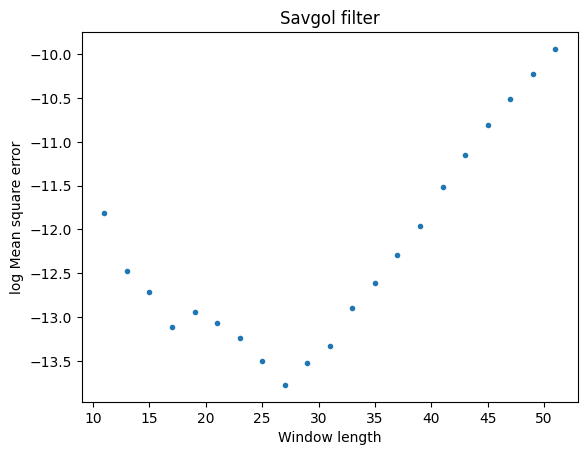

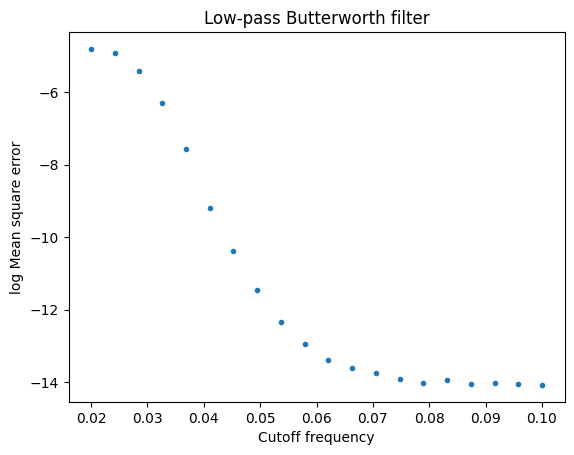

In [22]:
noise = np.random.normal(0,0.03,len(wavs))
R_noise = R_real+noise

i_tan, _ = find_peaks((4*n_f_val*d_f/wavs)%1)
m_max = 2*n_f_val[i_tan[0]]*d_f/wavs[i_tan[0]]
print(f'm0_max = {m_max}')
# lamb_1 = (2*n_f_val*d_f/(m_max))[0]
# lamb_2 = (2*n_f_val*d_f/(m_max-0.5))[0]
# freq_max = 0.5/(lamb_2-lamb_1)
freq_max = (2*n_f_val[0]*d_f)/wavs[0]**2
print(f'Maximum frequency = {freq_max} nm^-1')

#Savgol Filter
wind_lens = np.arange(11, 52, 2)
n_mse_svg = []

for wd_l in wind_lens:
    R = savgol_filter(R_noise, wd_l, 3)
    try:
        results = calc_values(R, wavs, n_s_val, "hermite")

        extr = np.sort(np.append(results['max_R'], results['min_R']))
        
        n_mse = mse(results['n2'], n_f_val[extr])
        n_mse_svg.append(n_mse)

        # print(f'Window lenght = {wd_l}, m0 = {results["m0_exact"]}')

    except ValueError as err:
        print(f'Error at window length = {wd_l}')
        n_mse_svg.append(1)
        # raise err

i_min = np.argmin(n_mse_svg)
print(f'Best window length = {wind_lens[i_min]}; MSE = {n_mse_svg[i_min]}')
plt.figure()
plt.title('Savgol filter')
plt.plot(wind_lens, np.log(n_mse_svg), '.')
plt.xlabel('Window length')
plt.ylabel('log Mean square error')

#Low pass Butterworth filter
order = 5
n = len(wavs)
fs = n/(wavs[n-1]-wavs[0])
# cutoff_factors = np.arange(10, 51, 10)
cutoff_lst = np.linspace(0.02, 0.1, 20)
n_mse_lp = []

for cutoff in cutoff_lst:
    # cutoff = fs/cut_fct
    b, a = butter(order, cutoff, fs=fs, btype='low', analog=False)
    R = filtfilt(b, a, R_noise)

    try:
        results = calc_values(R, wavs, n_s_val, "hermite")
        extr = np.sort(np.append(results['max_R'], results['min_R']))

        n_mse = mse(results['n2'], n_f_val[extr])
        n_mse_lp.append(n_mse)

        # print(f'Cutoff = {cutoff}; m0 = {results["m0_exact"]}')

    except ValueError:
        print(f'Error at cutoff frequency = {cutoff}')
        n_mse_lp.append(1)

i_min = np.argmin(n_mse_lp)
ideal_cuttoff = 1/(wavs[extr[2]]-wavs[extr[0]])
# print(f'{wavs[extr[0]]}, {lamb_1}; {wavs[extr[2]]}, {lamb_2}')
print(f'Best cutoff = {cutoff_lst[i_min]}; MSE = {n_mse_lp[i_min]}')
print(f'Min cuttoff = {freq_max}, {ideal_cuttoff}')
print(f'Best/Min cuttoff = {cutoff_lst[i_min]/freq_max}')
plt.figure()
plt.title('Low-pass Butterworth filter')
plt.plot(cutoff_lst, np.log(n_mse_lp), '.')
# plt.xlabel('Cutoff factor')
plt.xlabel('Cutoff frequency')
plt.ylabel('log Mean square error')

plt.show()